# VQC Based on IQC:AIL

## Imports

In [ ]:
import qiskit
from qiskit_machine_learning.algorithms import VQC
from qiskit.circuit import QuantumCircuit,Parameter
from qiskit.compiler import transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram, visualize_transition, plot_bloch_vector
from qiskit.circuit.library import UnitaryGate,Initialize
from qiskit.quantum_info import Statevector,partial_trace, DensityMatrix

import pennylane as qml
from pennylane import numpy as pnp
import qutip
from toqito import state_props

import numpy as np
from scipy.linalg import expm as expMatrix
from sympy.physics.quantum.dagger import Dagger
import math

from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold,train_test_split, KFold
from sklearn.datasets import make_circles
from sklearn.multiclass import OneVsRestClassifier
from sklearn.utils.multiclass import unique_labels
from sklearn.utils.validation import check_array, check_is_fitted, check_X_y
from sklearn.preprocessing import MinMaxScaler
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn import preprocessing
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score, make_scorer, roc_auc_score, classification_report

from imblearn.over_sampling import SMOTE
from ucimlrepo import fetch_ucirepo

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pdflatex

import pandas as pd

from all_iqc import *


## Base de Dados

In [4]:
#Parâmetros
RANDOM_SEED = 1
N_SAMPLES = 300
NOISE=0.05
N_FEATURES=2
N_PRINTINGS = N_SAMPLES//10
N_SHOTS=2048
LEARNING_RATE = 0.01
N_QUBITS=math.ceil(np.log2(N_FEATURES)+1) #Nqubits do circuito
weights=np.full(N_FEATURES,1)
QUBITS=[i for i in range(N_QUBITS)]
N_ITER=200

In [5]:
#Gerando o dataset
def generate_circles(n_samples, noise, factor, normalize_col=False, normalize_lin=False):
  X, y = make_circles(n_samples=n_samples, random_state=1, factor=factor, noise=noise)

  if normalize_col:
    scaler = MinMaxScaler()
    scaler.fit(X)
    X = scaler.transform(X)
  if normalize_lin:
    X = preprocessing.normalize(X,axis=1,norm='l2')


  return X, y

X_circles,y_circles=generate_circles(N_SAMPLES, 0.05, 0.5,normalize_lin=False)

## Tratamento do Dataset

In [ ]:
def normalize_iqc_ail(data, normalize_col=False, normalize_lin=False):
    if normalize_col:
        data = preprocessing.normalize(data,axis=0,norm='l2')
        '''
        Perceba que normalizando apenas a coluna, podemos ter amplitudes dos estados em que a norma do estado não fosse igual a 1. Para resolvermos isso, devemos
        normalizar as linhas entre si

        '''
        data = preprocessing.normalize(data,axis=1,norm='l2')
    if normalize_lin:
        data = preprocessing.normalize(data,axis=1,norm='l2') #Normaliza a linha entre [-1,1]
    return data
    
X_circles_iqc_ail_coluna=normalize_iqc_ail(X_circles, normalize_col=True, normalize_lin=False)
X_circles_iqc_ail_linha=normalize_iqc_ail(X_circles,normalize_col=False,normalize_lin=True)

#### Boxplot IQC:AIL Column Normalized

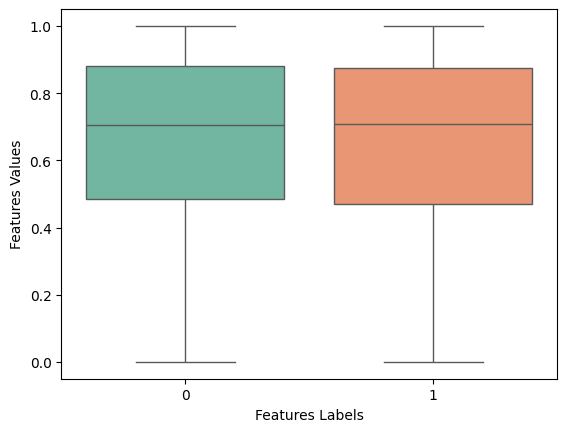

In [7]:
fig, ax = plt.subplots()
sns.boxplot(X_circles_iqc_ail_coluna, palette="Set2",ax=ax)
ax.set_xlabel('Features Labels')
ax.set_ylabel('Features Values')
plt.savefig('boxplot_circles_iqc_ail_coluna.svg')

#### Boxplot IQC:AIL Line Normalized

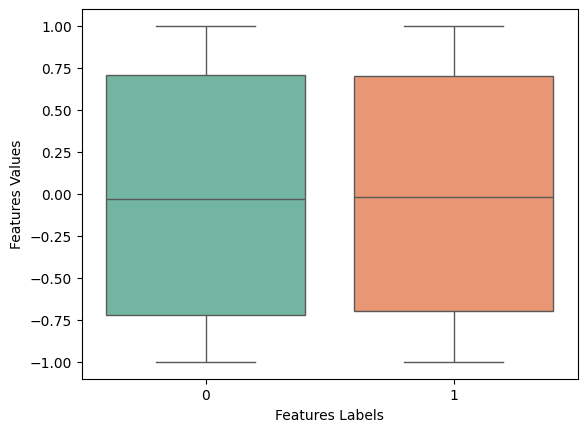

In [8]:
fig, ax = plt.subplots()
sns.boxplot(X_circles_iqc_ail_linha, palette="Set2",ax=ax)
ax.set_xlabel('Features Labels')
ax.set_ylabel('Features Values')
plt.savefig('boxplot_circles_iqc_ail_linha.svg')

## Função que junta tudo até agora

In [9]:
def blochvector(rho_cog,matriz_pauli_x,matriz_pauli_y,matriz_pauli_z):
    x_bloch = np.trace(matriz_pauli_x@rho_cog.data)
    y_bloch = np.trace(matriz_pauli_y@rho_cog.data)
    z_bloch = np.trace(matriz_pauli_z@rho_cog.data)
    return [x_bloch,y_bloch,z_bloch]
    
#Executar o circuito
def run_qasm_counts(qc, shots=N_SHOTS):
    qc.measure_all()
    qasm_simulator = Aer.get_backend("qasm_simulator")
    job = qasm_simulator.run(qc, shots=shots)
    result = job.result()
    return result.get_counts()

def cirq_iqc_ail(data,contador,w=weights,qubits=QUBITS, N_qubits=N_QUBITS, N_atributos=N_FEATURES, printar_cirq=False):

    X_blobs_new=list(data)
    if np.log2(N_atributos)%2!=0 and np.log2(N_atributos)!=1:
        for k in range(2**(N_qubits-1) - N_atributos):
            w=np.append(w,0)
            X_blobs_new=np.append(X_blobs_new,0)
        sigmaE=np.diag(w)
    else:
        sigmaE=np.diag(w)
    
    #Podíamos inicializar assim pra facilitar as contas
    '''x=np.random.rand(2**N_atributos)
    w=np.random.rand(2**N_atributos)'''

    # IQC:AIL

    qc = QuantumCircuit(N_qubits)

    qc.initialize(X_blobs_new, range(1,N_qubits))# Inicializaçao do estado inicial. Poderia ser qualquer estado.
    qc.h(0)

    #Montando os sigmas

    matriz_pauli_x=np.array([[0,1],[1,0]]) # Matriz de Pauli x
    matriz_pauli_y=np.array([[0,-1j],[1j,0]]) # Matriz de Pauli y
    matriz_pauli_z=np.array([[1,0],[0,-1]]) # Matriz de Pauli z

    sigmaQ=matriz_pauli_x+matriz_pauli_y+matriz_pauli_z

    

    #Operador Unitário
    U=np.matrix(expMatrix(1j*np.kron(sigmaQ,sigmaE)))

    # qubitstarget = [i for i in range(Ntarget)] - > Desnecessário agora, mas interessante para fazer a generalização
    qc.unitary(U,qubits)
    if contador==0:
        qc.draw("mpl", filename=f'./mpl_complete_U_blobs.svg')
    if printar_cirq==True:
        display(qc.draw('mpl')) #display(qc.draw("mpl", filename='./mpl_original.pdf')) #Trocar as chamadas se quiser salvar as imagens dos circuitos

    #qc.decompose().draw(output="mpl", style="clifford")
    qc = transpile(qc, optimization_level=3, basis_gates=["u3", "cx"])
    if dict(qc.count_ops())['u3']<=50 and dict(qc.count_ops())['cx']<=50 and contador%N_PRINTINGS==0:
        qc.draw("mpl", filename=f'./mpl_transpiled{contador}_blobs.svg')

    if printar_cirq==True and dict(qc.count_ops())['u3']<=50 and dict(qc.count_ops())['u3']<=50:
        print(dict(qc.count_ops()))
        display(qc.draw('mpl')) #display(qc.draw('mpl', filename='./mpl_transpile.pdf')) #Trocar as chamadas se quiser salvar as imagens dos circuitos

    # Mostrando o vetor de estado 
    sv = Statevector(qc)
    if contador%N_PRINTINGS==0:
        sv.draw("city", filename=f'./state_vector_city{contador}_blobs.svg')
        sv.draw("bloch", filename=f'./state_vector_bloch{contador}_blobs.svg')
        sv.draw("qsphere", filename=f'./state_vector_qsphere{contador}_blobs.svg')
    if printar_cirq==True:
        display(sv.draw("latex"))

    
    counts = run_qasm_counts(qc)
    if contador%N_PRINTINGS==0:
        plot_histogram(counts,filename=f'./histogram_plot_{contador}_blobs.svg')
    
    rho_cog=partial_trace(sv,qubits[1:])
    #rho_cog = partial_trace(DensityMatrix.from_instruction(qc), qubits[1:])
    if printar_cirq==True:
        print(rho_cog)

    return blochvector(rho_cog,matriz_pauli_x,matriz_pauli_y,matriz_pauli_z)

## Esfera de Bloch do Circuito

In [ ]:
def esfera_bloch_IQC(X,counter,norma,weights=weights,printar_esf=False):
    point_states=[]
    for k in range(0,N_SAMPLES):
        point_states.append(cirq_iqc_ail(X[k],k,w=weights))

    b = qutip.Bloch()
    b.point_default_color=['k']
    b.point_marker=['o']
    b.point_size=[15, 15, 15, 15]
    for k in range(len(point_states)):
        b.add_points(point_states[k])
    b.render()
    if printar_esf==True:
        b.show()

    bb = b.fig
    bb.savefig(f'Bloch_geral_circles{counter}_IQC_AIL_{norma}.svg')

z1=esfera_bloch_IQC(X_circles_iqc_ail_coluna,1,'coluna')
z2=esfera_bloch_IQC(X_circles_iqc_ail_linha,1,'linha')

## Treinamento

#### IQC AIL LINHA

In [29]:
'''
for SEED in range(n_times_kfold):
    scores, f1scores, output_dict = execute_training_test_k_fold(
                    X, 
                    y, 
                    k_folds=k_times_fold,
                    random_seed = SEED, 
                    classifier_function=classifier_function, 
                    dic_classifier_params=dic_classifier_params,
                    one_vs_classifier=OneVsRestClassifier, 
                    dic_training_params=dic_training_params,
                    print_each_fold_metric=True,
                    print_avg_metric=True)
    scores_list.append(scores)
    f1scores_list.append(f1scores)
    negativities_list.append(output_dict["negativities"])
'''

k_times_fold = 10
classifier_function = iqc_classifier
dic_classifier_params = {}
dic_classifier_params["sigma_q_params"] = [1,1,1,0]
dic_classifier_params["use_polar_coordinates_on_sigma_q"] = False
dic_classifier_params["load_inputvector_env_state"] = True
dic_classifier_params["normalize_axis"] = 1



dic_training_params = {"max_iter": 10,
    "accuracy_succ": 0.99,
    "plot_graphs_and_metrics": False,
    "plot_graphs_in_classifier": False,
    "random_seed": 1,
    "learning_rate": 0.01,
    "refit_db":True,
    "reset_weights_epoch":0,
    "do_classes_refit":True,
    "batch":False}


N_SAMPLES=600
FACTOR_LIST=[0.2,0.5]
NOISE_LIST=[0.05,0.3]
scores_list = []
f1scores_list = []
negativities_list = []
for factor in FACTOR_LIST:
    for noise in NOISE_LIST:
        """Creating a dataset with different settings"""
        X_blobs,y_blobs=generate_circles(N_SAMPLES, noise, factor, normalize_col=False, normalize_lin=False)
        scores_list = []
        f1scores_list = []
        negativities_list = []
        scores, f1scores, output_dict = execute_training_test_k_fold(
                        X_blobs, 
                        y_blobs, 
                        k_folds=k_times_fold,
                        random_seed = 1, 
                        classifier_function=classifier_function, 
                        dic_classifier_params=dic_classifier_params,
                        one_vs_classifier=OneVsRestClassifier, 
                        dic_training_params=dic_training_params,
                        print_each_fold_metric=True,
                        print_avg_metric=True)
        scores_list.append(scores)
        f1scores_list.append(f1scores)
        negativities_list.append(output_dict["negativities"])
        print("Media Score dos N K-Fold", np.mean([np.mean(i) for i in scores_list]))
        print("Maior Score dos K-Fold", max([np.mean(i) for i in scores_list]))
        print("Min Score dos K-Fold", min([np.mean(i) for i in scores_list]))

        print("Media Score dos K-Fold", [np.mean(i) for i in scores_list])

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


K-Fold #0
Mean negativities for all classes: [np.float64(0.2245655607693337)]
              precision    recall  f1-score   support

           0       0.54      0.67      0.60        30
           1       0.57      0.43      0.49        30

    accuracy                           0.55        60
   macro avg       0.55      0.55      0.54        60
weighted avg       0.55      0.55      0.54        60

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


K-Fold #1
Mean negativities for all classes: [np.float64(0.22446009032296887)]
              precision    recall  f1-score   support

           0       0.49      0.63      0.55        30
           1       0.48      0.33      0.39        30

    accuracy                           0.48        60
   macro avg       0.48      0.48      0.47        60
weighted avg       0.48      0.48      0.47        60

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


...

K-Fold #7
Mean negativities for all classes: [np.float64(0.24968884597607252)]
              precision    recall  f1-score   support

           0       0.52      0.77      0.62        30
           1       0.56      0.30      0.39        30

    accuracy                           0.53        60
   macro avg       0.54      0.53      0.51        60
weighted avg       0.54      0.53      0.51        60

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


K-Fold #8
Mean negativities for all classes: [np.float64(0.24734273639532475)]
              precision    recall  f1-score   support

           0       0.48      0.67      0.56        30
           1       0.44      0.27      0.33        30

    accuracy                           0.47        60
   macro avg       0.46      0.47      0.44        60
weighted avg       0.46      0.47      0.44        60

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


K-Fold #9
Mean negativities for all classes: [np.float64(0.27146852197206855)]
              precision    recall  f1-score   support

           0       0.48      0.77      0.59        30
           1       0.42      0.17      0.24        30

    accuracy                           0.47        60
   macro avg       0.45      0.47      0.41        60
weighted avg       0.45      0.47      0.41        60

-------------------------------------------------------------------------------------------------------------------
AVG: Scores = 0.5083333333333334 F1-Scores = 0.48573902059374535 Negativity = [np.float64(0.2050940087427994), np.float64(0.1968302765301179)]
Media Score dos N K-Fold 0.5083333333333334
Maior Score dos K-Fold 0.5083333333333334
Min Score dos K-Fold 0.5083333333333334
Media Score dos K-Fold [np.float64(0.5083333333333334)]


#### IQC AIL COLUNA

In [30]:
'''
for SEED in range(n_times_kfold):
    scores, f1scores, output_dict = execute_training_test_k_fold(
                    X, 
                    y, 
                    k_folds=k_times_fold,
                    random_seed = SEED, 
                    classifier_function=classifier_function, 
                    dic_classifier_params=dic_classifier_params,
                    one_vs_classifier=OneVsRestClassifier, 
                    dic_training_params=dic_training_params,
                    print_each_fold_metric=True,
                    print_avg_metric=True)
    scores_list.append(scores)
    f1scores_list.append(f1scores)
    negativities_list.append(output_dict["negativities"])
'''

k_times_fold = 10
classifier_function = iqc_classifier
dic_classifier_params = {}
dic_classifier_params["sigma_q_params"] = [1,1,1,0]
dic_classifier_params["use_polar_coordinates_on_sigma_q"] = False
dic_classifier_params["load_inputvector_env_state"] = True
dic_classifier_params["normalize_axis"] = 0



dic_training_params = {"max_iter": 10,
    "accuracy_succ": 0.99,
    "plot_graphs_and_metrics": False,
    "plot_graphs_in_classifier": False,
    "random_seed": 1,
    "learning_rate": 0.01,
    "refit_db":True,
    "reset_weights_epoch":0,
    "do_classes_refit":True,
    "batch":False}


N_SAMPLES=600
FACTOR_LIST=[0.2,0.5]
NOISE_LIST=[0.05,0.3]
scores_list = []
f1scores_list = []
negativities_list = []
for factor in FACTOR_LIST:
    for noise in NOISE_LIST:
        """Creating a dataset with different settings"""
        X_blobs,y_blobs=generate_circles(N_SAMPLES, noise, factor, normalize_col=False, normalize_lin=False)
        scores_list = []
        f1scores_list = []
        negativities_list = []
        scores, f1scores, output_dict = execute_training_test_k_fold(
                        X_blobs, 
                        y_blobs, 
                        k_folds=k_times_fold,
                        random_seed = 1, 
                        classifier_function=classifier_function, 
                        dic_classifier_params=dic_classifier_params,
                        one_vs_classifier=OneVsRestClassifier, 
                        dic_training_params=dic_training_params,
                        print_each_fold_metric=True,
                        print_avg_metric=True)
        scores_list.append(scores)
        f1scores_list.append(f1scores)
        negativities_list.append(output_dict["negativities"])
        print("Media Score dos N K-Fold", np.mean([np.mean(i) for i in scores_list]))
        print("Maior Score dos K-Fold", max([np.mean(i) for i in scores_list]))
        print("Min Score dos K-Fold", min([np.mean(i) for i in scores_list]))

        print("Media Score dos K-Fold", [np.mean(i) for i in scores_list])

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


K-Fold #0
Mean negativities for all classes: [np.float64(0.22314821081081831)]
              precision    recall  f1-score   support

           0       0.54      0.67      0.60        30
           1       0.57      0.43      0.49        30

    accuracy                           0.55        60
   macro avg       0.55      0.55      0.54        60
weighted avg       0.55      0.55      0.54        60

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


K-Fold #1
Mean negativities for all classes: [np.float64(0.20826054148377143)]
              precision    recall  f1-score   support

           0       0.49      0.63      0.55        30
           1       0.48      0.33      0.39        30

    accuracy                           0.48        60
   macro avg       0.48      0.48      0.47        60
weighted avg       0.48      0.48      0.47        60

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


...

K-Fold #7
Mean negativities for all classes: [np.float64(0.24089802033091468)]
              precision    recall  f1-score   support

           0       0.52      0.77      0.62        30
           1       0.56      0.30      0.39        30

    accuracy                           0.53        60
   macro avg       0.54      0.53      0.51        60
weighted avg       0.54      0.53      0.51        60

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


K-Fold #8
Mean negativities for all classes: [np.float64(0.24210974886704775)]
              precision    recall  f1-score   support

           0       0.48      0.67      0.56        30
           1       0.44      0.27      0.33        30

    accuracy                           0.47        60
   macro avg       0.46      0.47      0.44        60
weighted avg       0.46      0.47      0.44        60

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


K-Fold #9
Mean negativities for all classes: [np.float64(0.26351906123173197)]
              precision    recall  f1-score   support

           0       0.47      0.77      0.58        30
           1       0.36      0.13      0.20        30

    accuracy                           0.45        60
   macro avg       0.42      0.45      0.39        60
weighted avg       0.42      0.45      0.39        60

-------------------------------------------------------------------------------------------------------------------
AVG: Scores = 0.5033333333333333 F1-Scores = 0.48233784411851516 Negativity = [np.float64(0.20530166129777588), np.float64(0.19794853526025674)]
Media Score dos N K-Fold 0.5033333333333333
Maior Score dos K-Fold 0.5033333333333333
Min Score dos K-Fold 0.5033333333333333
Media Score dos K-Fold [np.float64(0.5033333333333333)]


#### IQC LINHA

In [31]:
'''
for SEED in range(n_times_kfold):
    scores, f1scores, output_dict = execute_training_test_k_fold(
                    X, 
                    y, 
                    k_folds=k_times_fold,
                    random_seed = SEED, 
                    classifier_function=classifier_function, 
                    dic_classifier_params=dic_classifier_params,
                    one_vs_classifier=OneVsRestClassifier, 
                    dic_training_params=dic_training_params,
                    print_each_fold_metric=True,
                    print_avg_metric=True)
    scores_list.append(scores)
    f1scores_list.append(f1scores)
    negativities_list.append(output_dict["negativities"])
'''

k_times_fold = 10
classifier_function = iqc_classifier
dic_classifier_params = {}
dic_classifier_params["sigma_q_params"] = [1,1,1,0]
dic_classifier_params["use_polar_coordinates_on_sigma_q"] = False
dic_classifier_params["load_inputvector_env_state"] = False
dic_classifier_params["normalize_axis"] = 1



dic_training_params = {"max_iter": 10,
    "accuracy_succ": 0.99,
    "plot_graphs_and_metrics": False,
    "plot_graphs_in_classifier": False,
    "random_seed": 1,
    "learning_rate": 0.01,
    "refit_db":True,
    "reset_weights_epoch":0,
    "do_classes_refit":True,
    "batch":False}


N_SAMPLES=600
FACTOR_LIST=[0.2,0.5]
NOISE_LIST=[0.05,0.3]
scores_list = []
f1scores_list = []
negativities_list = []
for factor in FACTOR_LIST:
    for noise in NOISE_LIST:
        """Creating a dataset with different settings"""
        X_blobs,y_blobs=generate_circles(N_SAMPLES, noise, factor, normalize_col=False, normalize_lin=False)
        scores_list = []
        f1scores_list = []
        negativities_list = []
        scores, f1scores, output_dict = execute_training_test_k_fold(
                        X_blobs, 
                        y_blobs, 
                        k_folds=k_times_fold,
                        random_seed = 1, 
                        classifier_function=classifier_function, 
                        dic_classifier_params=dic_classifier_params,
                        one_vs_classifier=OneVsRestClassifier, 
                        dic_training_params=dic_training_params,
                        print_each_fold_metric=True,
                        print_avg_metric=True)
        scores_list.append(scores)
        f1scores_list.append(f1scores)
        negativities_list.append(output_dict["negativities"])
        print("Media Score dos N K-Fold", np.mean([np.mean(i) for i in scores_list]))
        print("Maior Score dos K-Fold", max([np.mean(i) for i in scores_list]))
        print("Min Score dos K-Fold", min([np.mean(i) for i in scores_list]))

        print("Media Score dos K-Fold", [np.mean(i) for i in scores_list])

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


K-Fold #0
Mean negativities for all classes: [np.float64(0.315072100641457)]
              precision    recall  f1-score   support

           0       0.52      0.93      0.67        30
           1       0.67      0.13      0.22        30

    accuracy                           0.53        60
   macro avg       0.59      0.53      0.44        60
weighted avg       0.59      0.53      0.44        60

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


K-Fold #1
Mean negativities for all classes: [np.float64(0.35134214296380345)]
              precision    recall  f1-score   support

           0       0.49      0.93      0.64        30
           1       0.33      0.03      0.06        30

    accuracy                           0.48        60
   macro avg       0.41      0.48      0.35        60
weighted avg       0.41      0.48      0.35        60

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


...

K-Fold #7
Mean negativities for all classes: [np.float64(0.29866371572584155)]
              precision    recall  f1-score   support

           0       0.51      0.87      0.64        30
           1       0.56      0.17      0.26        30

    accuracy                           0.52        60
   macro avg       0.53      0.52      0.45        60
weighted avg       0.53      0.52      0.45        60

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


K-Fold #8
Mean negativities for all classes: [np.float64(0.29730868417094)]
              precision    recall  f1-score   support

           0       0.51      1.00      0.67        30
           1       1.00      0.03      0.06        30

    accuracy                           0.52        60
   macro avg       0.75      0.52      0.37        60
weighted avg       0.75      0.52      0.37        60

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


K-Fold #9
Mean negativities for all classes: [np.float64(0.321550817721924)]
              precision    recall  f1-score   support

           0       0.47      0.83      0.60        30
           1       0.29      0.07      0.11        30

    accuracy                           0.45        60
   macro avg       0.38      0.45      0.36        60
weighted avg       0.38      0.45      0.36        60

-------------------------------------------------------------------------------------------------------------------
AVG: Scores = 0.4966666666666667 F1-Scores = 0.3824921691362603 Negativity = [np.float64(0.3338975752689884), np.float64(0.3467327246076288)]
Media Score dos N K-Fold 0.4966666666666667
Maior Score dos K-Fold 0.4966666666666667
Min Score dos K-Fold 0.4966666666666667
Media Score dos K-Fold [np.float64(0.4966666666666667)]


#### IQC COLUNA

In [32]:
'''
for SEED in range(n_times_kfold):
    scores, f1scores, output_dict = execute_training_test_k_fold(
                    X, 
                    y, 
                    k_folds=k_times_fold,
                    random_seed = SEED, 
                    classifier_function=classifier_function, 
                    dic_classifier_params=dic_classifier_params,
                    one_vs_classifier=OneVsRestClassifier, 
                    dic_training_params=dic_training_params,
                    print_each_fold_metric=True,
                    print_avg_metric=True)
    scores_list.append(scores)
    f1scores_list.append(f1scores)
    negativities_list.append(output_dict["negativities"])
'''

k_times_fold = 10
classifier_function = iqc_classifier
dic_classifier_params = {}
dic_classifier_params["sigma_q_params"] = [1,1,1,0]
dic_classifier_params["use_polar_coordinates_on_sigma_q"] = False
dic_classifier_params["load_inputvector_env_state"] = False
dic_classifier_params["normalize_axis"] = 0



dic_training_params = {"max_iter": 10,
    "accuracy_succ": 0.99,
    "plot_graphs_and_metrics": False,
    "plot_graphs_in_classifier": False,
    "random_seed": 1,
    "learning_rate": 0.01,
    "refit_db":True,
    "reset_weights_epoch":0,
    "do_classes_refit":True,
    "batch":False}


N_SAMPLES=600
FACTOR_LIST=[0.2,0.5]
NOISE_LIST=[0.05,0.3]
scores_list = []
f1scores_list = []
negativities_list = []
for factor in FACTOR_LIST:
    for noise in NOISE_LIST:
        """Creating a dataset with different settings"""
        X_blobs,y_blobs=generate_circles(N_SAMPLES, noise, factor, normalize_col=False, normalize_lin=False)
        scores_list = []
        f1scores_list = []
        negativities_list = []
        scores, f1scores, output_dict = execute_training_test_k_fold(
                        X_blobs, 
                        y_blobs, 
                        k_folds=k_times_fold,
                        random_seed = 1, 
                        classifier_function=classifier_function, 
                        dic_classifier_params=dic_classifier_params,
                        one_vs_classifier=OneVsRestClassifier, 
                        dic_training_params=dic_training_params,
                        print_each_fold_metric=True,
                        print_avg_metric=True)
        scores_list.append(scores)
        f1scores_list.append(f1scores)
        negativities_list.append(output_dict["negativities"])
        print("Media Score dos N K-Fold", np.mean([np.mean(i) for i in scores_list]))
        print("Maior Score dos K-Fold", max([np.mean(i) for i in scores_list]))
        print("Min Score dos K-Fold", min([np.mean(i) for i in scores_list]))

        print("Media Score dos K-Fold", [np.mean(i) for i in scores_list])

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


K-Fold #0
Mean negativities for all classes: [np.float64(0.31510196084938763)]
              precision    recall  f1-score   support

           0       0.52      0.93      0.67        30
           1       0.67      0.13      0.22        30

    accuracy                           0.53        60
   macro avg       0.59      0.53      0.44        60
weighted avg       0.59      0.53      0.44        60

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


K-Fold #1
Mean negativities for all classes: [np.float64(0.3514360770367863)]
              precision    recall  f1-score   support

           0       0.49      0.93      0.64        30
           1       0.33      0.03      0.06        30

    accuracy                           0.48        60
   macro avg       0.41      0.48      0.35        60
weighted avg       0.41      0.48      0.35        60

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


...

K-Fold #7
Mean negativities for all classes: [np.float64(0.3002760395694509)]
              precision    recall  f1-score   support

           0       0.51      0.87      0.64        30
           1       0.56      0.17      0.26        30

    accuracy                           0.52        60
   macro avg       0.53      0.52      0.45        60
weighted avg       0.53      0.52      0.45        60

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


K-Fold #8
Mean negativities for all classes: [np.float64(0.296293897056125)]
              precision    recall  f1-score   support

           0       0.50      0.97      0.66        30
           1       0.50      0.03      0.06        30

    accuracy                           0.50        60
   macro avg       0.50      0.50      0.36        60
weighted avg       0.50      0.50      0.36        60

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


K-Fold #9
Mean negativities for all classes: [np.float64(0.3253380225835247)]
              precision    recall  f1-score   support

           0       0.47      0.83      0.60        30
           1       0.29      0.07      0.11        30

    accuracy                           0.45        60
   macro avg       0.38      0.45      0.36        60
weighted avg       0.38      0.45      0.36        60

-------------------------------------------------------------------------------------------------------------------
AVG: Scores = 0.4966666666666667 F1-Scores = 0.3816216272931127 Negativity = [np.float64(0.33121012279301376), np.float64(0.3460180339040918)]
Media Score dos N K-Fold 0.4966666666666667
Maior Score dos K-Fold 0.4966666666666667
Min Score dos K-Fold 0.4966666666666667
Media Score dos K-Fold [np.float64(0.4966666666666667)]


## Debugging

### Angle Embedding Qiskit

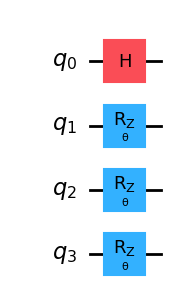

In [65]:
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter

custom_circ = QuantumCircuit(N_qubits)
theta = Parameter("\u03B8")
custom_circ.h(0)
custom_circ.rz(theta, range(1,N_qubits))
custom_circ.draw('mpl')

### Amplitude Embedding Pennylane

In [ ]:
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter

N_atributos=N_FEATURES
lista=[i for i in range(len(X_circles))]
j=int(np.random.choice(lista))

w=np.full(N_atributos,1)

#x=np.random.rand(N_atributos)
#w=np.random.rand(N_atributos)

N_qubits=math.ceil(np.log2(N_atributos)+1) #Nqubits do circuito

#Podíamos inicializar assim pra facilitar as contas
'''x=np.random.rand(2**N_atributos)
w=np.random.rand(2**N_atributos)'''

#Montando os sigmas

matriz_pauli_x=np.array([[0,1],[1,0]]) # Matriz de Pauli x
matriz_pauli_y=np.array([[0,-1j],[1j,0]]) # Matriz de Pauli y
matriz_pauli_z=np.array([[1,0],[0,-1]]) # Matriz de Pauli z

sigmaQ=matriz_pauli_x+matriz_pauli_y+matriz_pauli_z



X_circles_new=list(X_circles[j])
if np.log2(N_atributos)%2!=0 and np.log2(N_atributos)!=1:
    for k in range(2**(N_qubits-1) - N_atributos):
        X_circles_new.append(0)
        w=np.append(w,0)
    sigmaE=np.diag(X_circles_new)*w.T
else:
    sigmaE=np.diag(X_circles_new)*w.T

#Operador Unitário
U=np.matrix(expMatrix(1j*np.kron(sigmaQ,sigmaE)))

dev = qml.device("default.qubit", wires = qubits)

@qml.qnode(dev)
def circuit(f=None):
    qml.AmplitudeEmbedding(features=f,wires=range(1,N_qubits), pad_with=0.)
    qml.QubitUnitary(U, wires=qubits)

    return qml.density_matrix([0]) #Retorna a matriz reduzida do qubit alvo

rho=circuit(np.ones(N_qubits-1))
qml.drawer.use_style('pennylane')
fig, ax = qml.draw_mpl()()
ax.set_aspect('equal')
fig.set_figwidth(20)
plt.title("Circuit",size = 20)
plt.show()


NameError: name 'qubits' is not defined

### Angle Embedding Pennylane

In [ ]:
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter

'''custom_circ = QuantumCircuit(N_qubits)
theta = Parameter("\u03B8")
custom_circ.h(0)
custom_circ.rz(theta, range(1,N_qubits))
custom_circ.draw('mpl')'''

#my_qc=qml.from_qiskit(custom_circ, measurements=None)

dev = qml.device("default.qubit", wires = qubits)

@qml.qnode(dev)
def circuit(f=None):
    qml.AmplitudeEmbedding(features=f,wires=(1,N_qubits))
    qml.QubitUnitary(U, wires=qubits)

    return qml.density_matrix([0]) #Retorna a matriz reduzida do qubit alvo
qml.drawer.use_style('pennylane')
fig, ax = qml.draw_mpl(circuit)()
ax.set_aspect('equal')
fig.set_figwidth(20)
plt.title("Circuit",size = 20)
plt.show()
